In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kamilpytlak/personal-key-indicators-of-heart-disease")

print("Path to dataset files:", path)

100%|██████████| 21.4M/21.4M [00:00<00:00, 37.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kamilpytlak/personal-key-indicators-of-heart-disease/versions/6


In [2]:
import pandas as pd

df = pd.read_csv(path + "/2020/heart_2020_cleaned.csv")

df.head(10)

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
5,Yes,28.87,Yes,No,No,6.0,0.0,Yes,Female,75-79,Black,No,No,Fair,12.0,No,No,No
6,No,21.63,No,No,No,15.0,0.0,No,Female,70-74,White,No,Yes,Fair,4.0,Yes,No,Yes
7,No,31.64,Yes,No,No,5.0,0.0,Yes,Female,80 or older,White,Yes,No,Good,9.0,Yes,No,No
8,No,26.45,No,No,No,0.0,0.0,No,Female,80 or older,White,"No, borderline diabetes",No,Fair,5.0,No,Yes,No
9,No,40.69,No,No,No,0.0,0.0,Yes,Male,65-69,White,No,Yes,Good,10.0,No,No,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [4]:
df.duplicated().sum()

np.int64(18078)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.isnull().sum()

,0
HeartDisease,0
BMI,0
Smoking,0
AlcoholDrinking,0
Stroke,0
PhysicalHealth,0
MentalHealth,0
DiffWalking,0
Sex,0
AgeCategory,0


In [7]:
cal_cate=df.select_dtypes(include=['object']).columns
cal_cate

Index(['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking',
       'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity',
       'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

In [8]:
cal_num=df.select_dtypes(include=['int64','float64']).columns
cal_num

Index(['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime'], dtype='object')

In [9]:
df.AgeCategory.unique()

array(['55-59', '80 or older', '65-69', '75-79', '40-44', '70-74',
       '60-64', '50-54', '45-49', '18-24', '35-39', '30-34', '25-29'],
      dtype=object)

In [10]:
df.AgeCategory.value_counts()

,count
AgeCategory,
65-69,31670
60-64,31219
70-74,29273
55-59,27610
50-54,23736
80 or older,23352
75-79,20713
45-49,20518
18-24,19998


In [11]:
df[cal_cate].describe()

,HeartDisease,Smoking,AlcoholDrinking,Stroke,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,Asthma,KidneyDisease,SkinCancer
count,301717,301717,301717,301717,301717,301717,301717,301717,301717,301717,301717,301717,301717,301717
unique,2,2,2,2,2,2,13,6,4,2,5,2,2,2
top,No,No,No,No,No,Female,65-69,White,No,Yes,Very good,No,No,No
freq,274456,174312,280136,289653,257362,159671,31670,227724,251796,230412,104796,259066,289941,272425


In [12]:
df[cal_num].describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,301717.000000,301717.000000,301717.000000,301717.000000
mean,28.441970,3.572298,4.121475,7.084559
std,6.468134,8.140656,8.128288,1.467122
min,12.020000,0.000000,0.000000,1.000000
25%,24.030000,0.000000,0.000000,6.000000
50%,27.410000,0.000000,0.000000,7.000000
75%,31.650000,2.000000,4.000000,8.000000
max,94.850000,30.000000,30.000000,24.000000


In [13]:
df.HeartDisease.value_counts()

,count
HeartDisease,
No,274456
Yes,27261


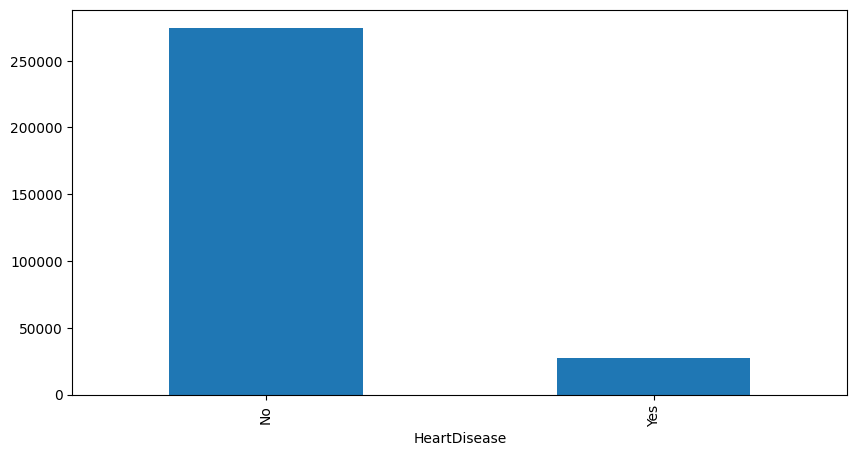

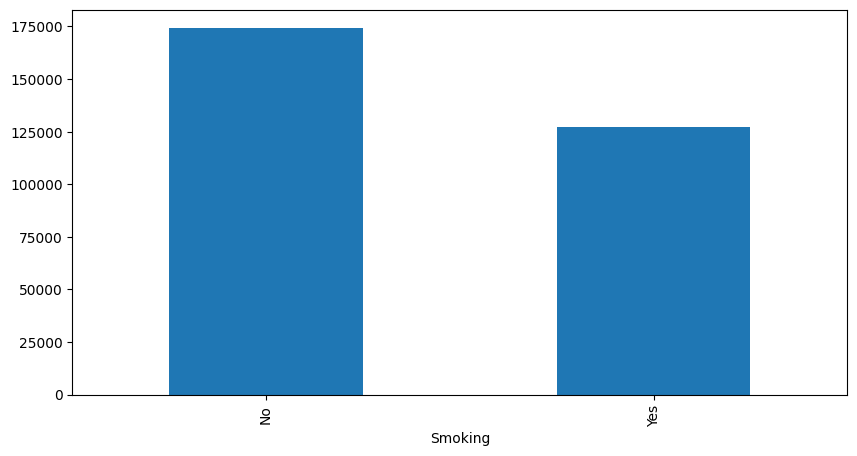

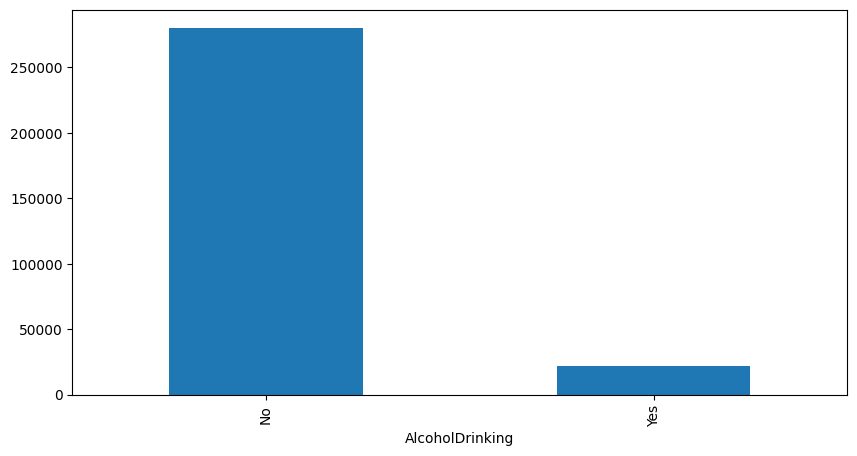

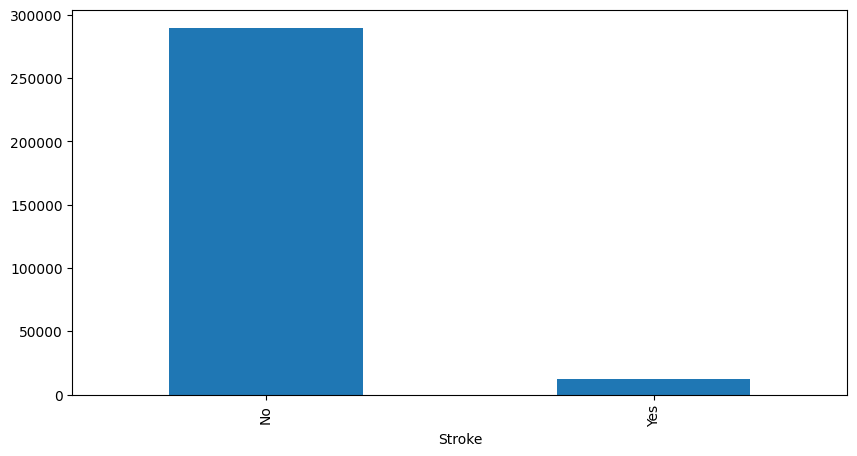

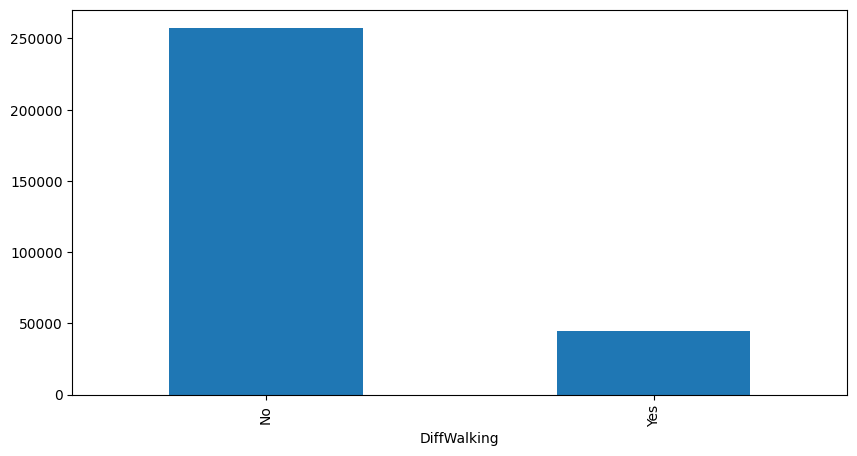

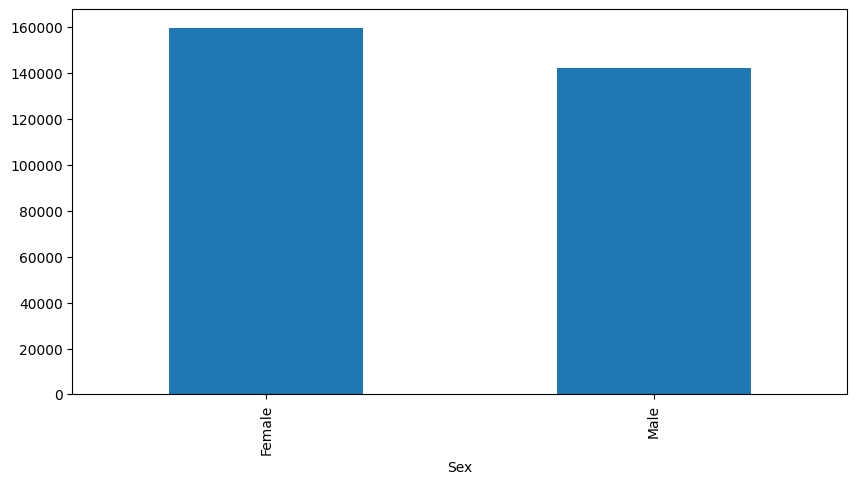

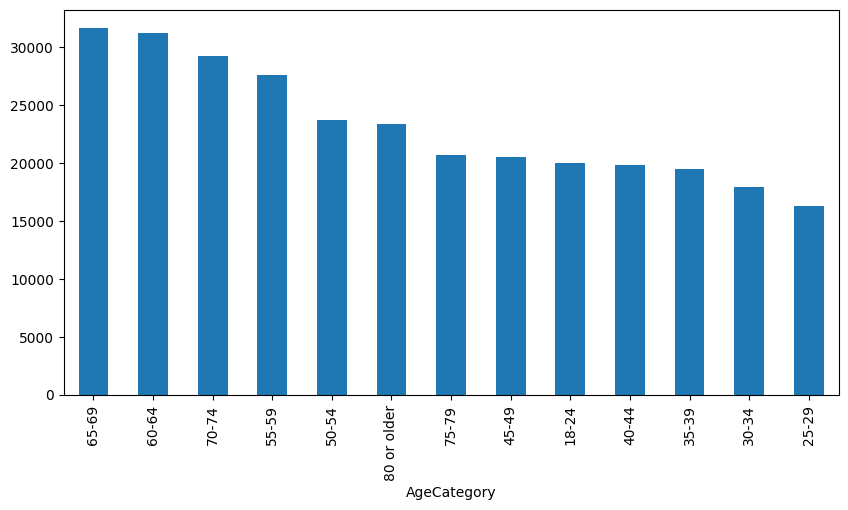

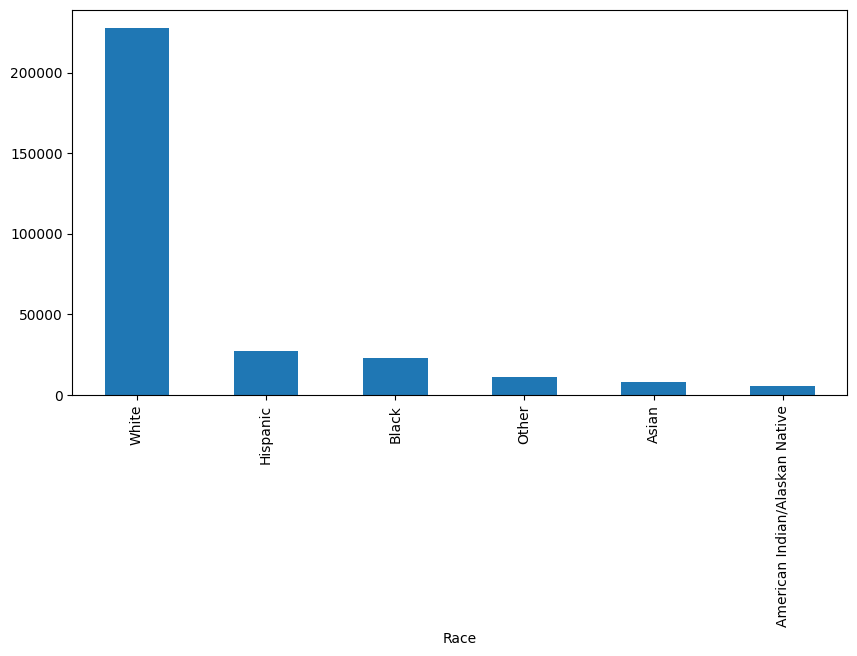

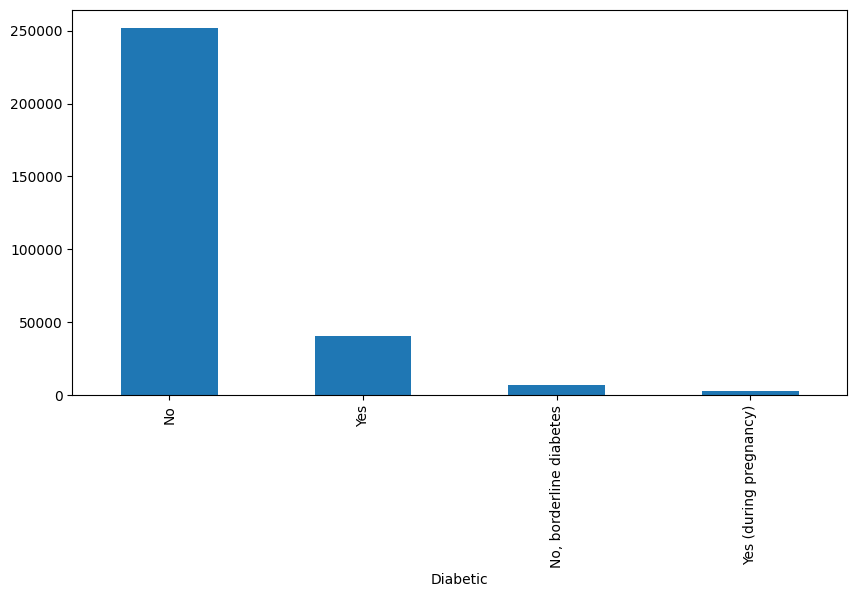

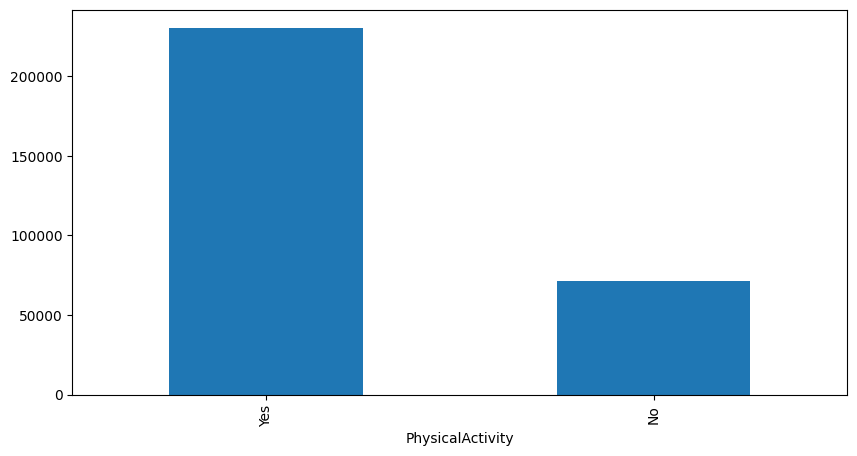

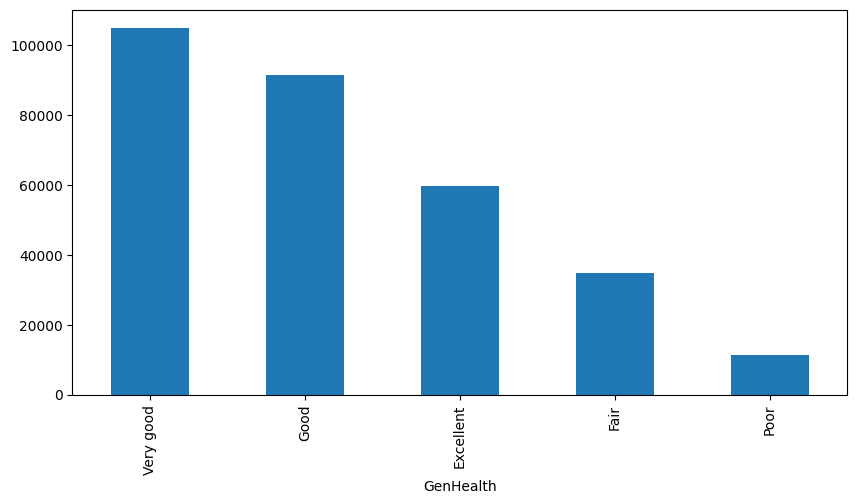

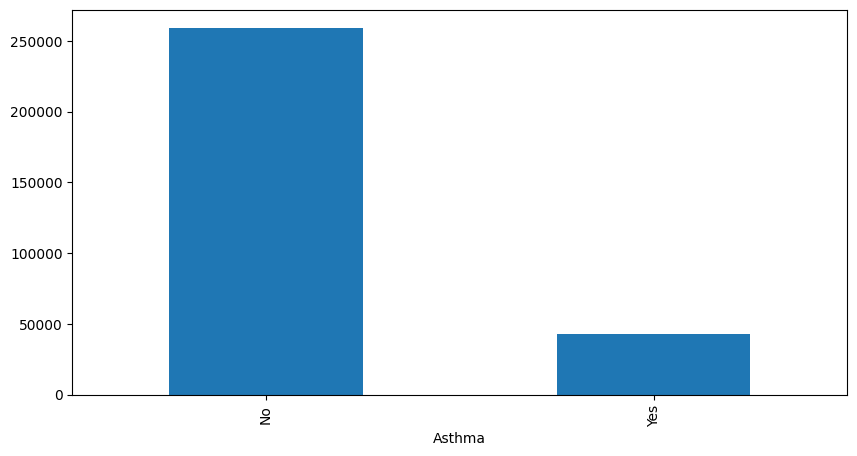

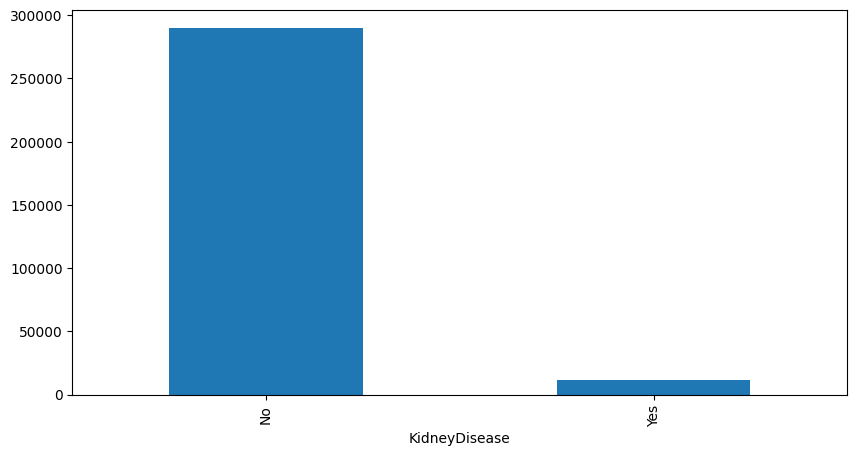

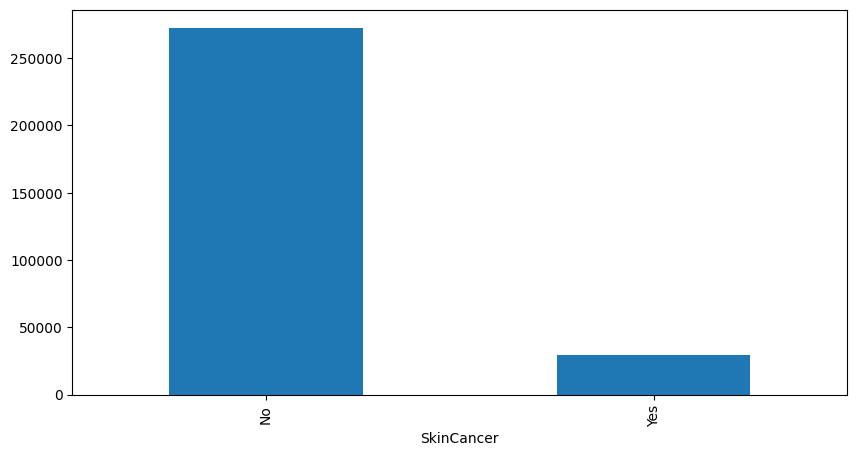

In [14]:

import matplotlib.pyplot as plt
for var in cal_cate:
    plt.figure(figsize=(10,5))
    df[var].value_counts().plot(kind='bar')

    plt.show()


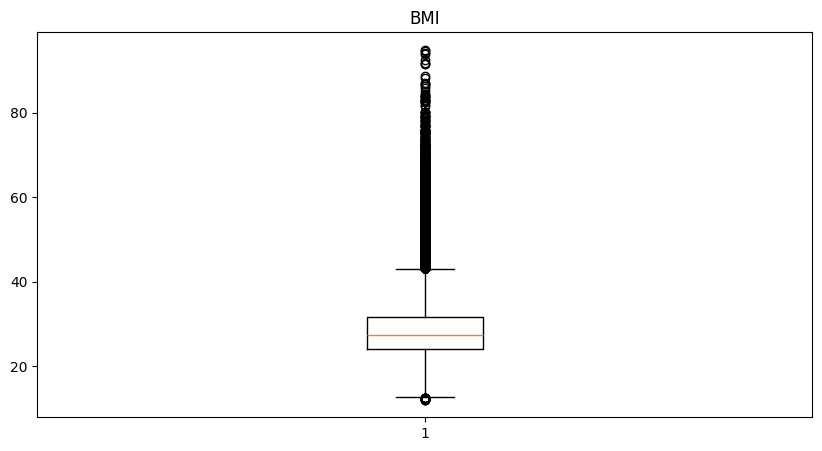

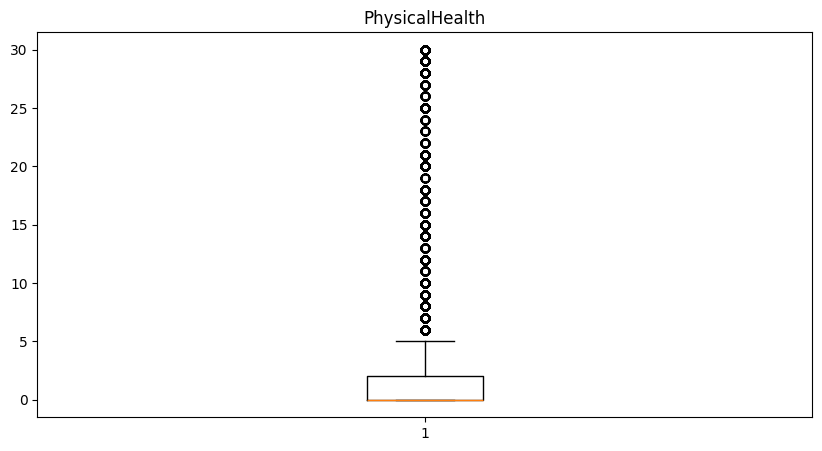

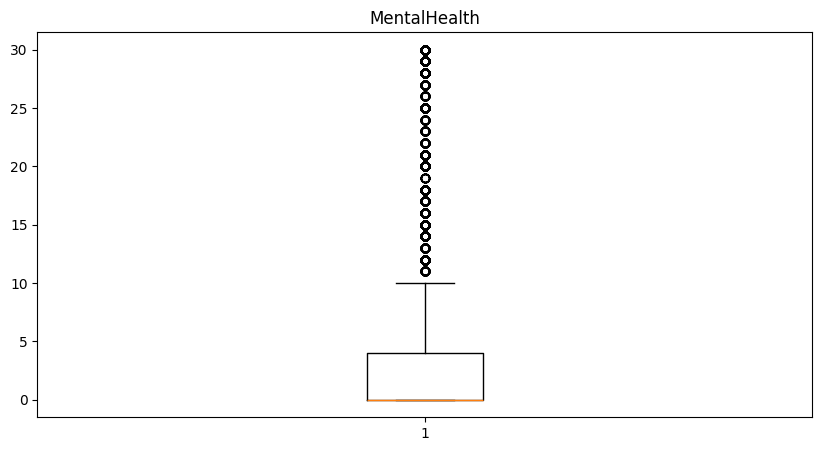

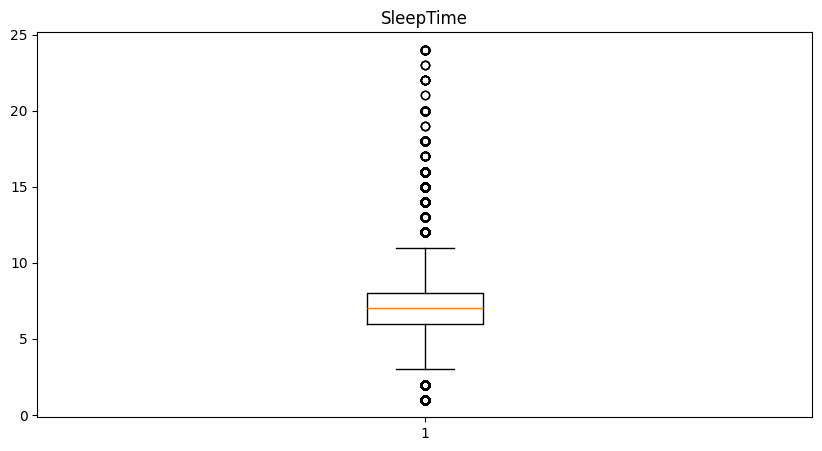

In [15]:
for var in cal_num:
    plt.figure(figsize=(10,5))
    plt.title(var)
    plt.boxplot(df[var])

    plt.show()

data Analysis

In [16]:
cal_cate

Index(['HeartDisease', 'Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking',
       'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity',
       'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

In [17]:
cal_num

Index(['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime'], dtype='object')

<Axes: xlabel='HeartDisease'>

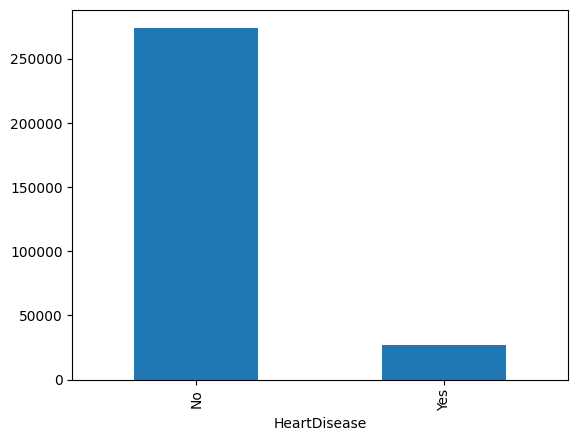

In [18]:
df.groupby('HeartDisease')["PhysicalHealth"].count().plot(kind='bar')


<Axes: xlabel='HeartDisease'>

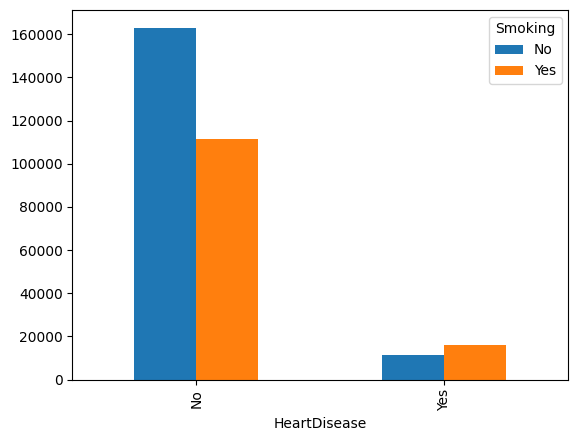

In [19]:
pd.crosstab(df.HeartDisease,df.Smoking).plot(kind='bar')

<Axes: xlabel='HeartDisease'>

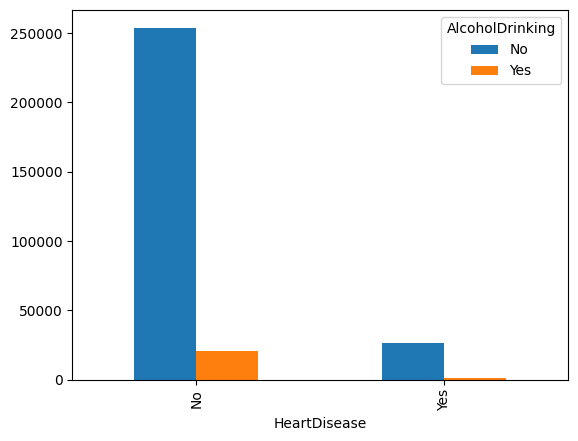

In [20]:
pd.crosstab(df.HeartDisease,df.AlcoholDrinking,).plot(kind='bar')

<Axes: xlabel='HeartDisease'>

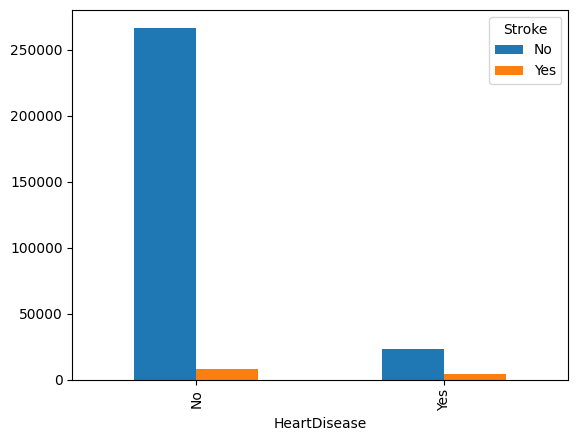

In [21]:
pd.crosstab(df.HeartDisease,df.Stroke).plot(kind='bar')

<Axes: xlabel='HeartDisease'>

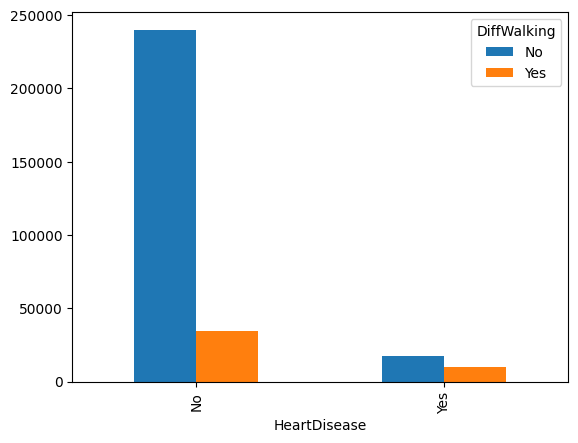

In [22]:
pd.crosstab(df.HeartDisease,df.DiffWalking).plot(kind='bar')

<Axes: xlabel='HeartDisease,Sex'>

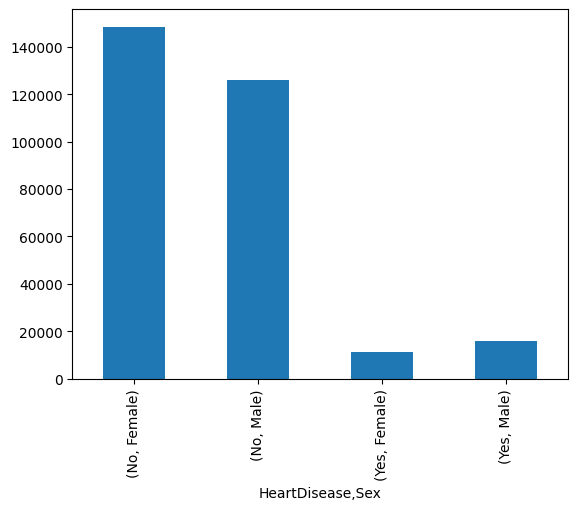

In [23]:
df.groupby(['HeartDisease',"Sex"])["MentalHealth"].count().plot(kind='bar')

In [24]:
df.groupby(['HeartDisease','AgeCategory',])['SleepTime'].mean().unstack()


AgeCategory,18-24,25-29,30-34,35-39,40-44,45-49,50-54,55-59,60-64,65-69,70-74,75-79,80 or older
HeartDisease,,,,,,,,,,,,,
No,7.171733,6.977811,6.862526,6.846698,6.874477,6.903666,6.921890,6.963756,7.056886,7.200862,7.306060,7.410344,7.541337
Yes,7.476923,6.533835,6.530973,6.351351,6.314815,6.506057,6.657267,6.755798,6.921710,7.077565,7.246419,7.398808,7.523406


<Axes: xlabel='Sex'>

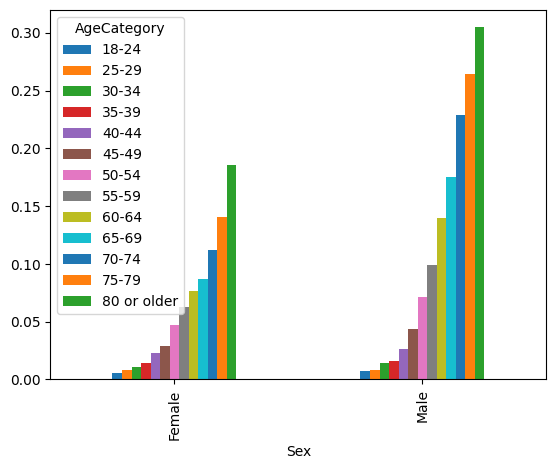

In [25]:
pd.crosstab(df['Sex'], df['AgeCategory'], values=df['HeartDisease'] == 'Yes', aggfunc='mean').plot(kind='bar')


<Axes: xlabel='Sex'>

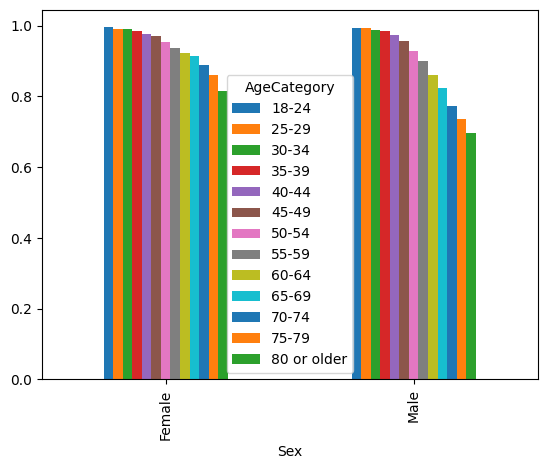

In [26]:
pd.crosstab(df['Sex'], df['AgeCategory'], values=df['HeartDisease'] == 'No', aggfunc='mean').plot(kind='bar')


Text(0.5, 1.0, 'Correlation between numerical features')

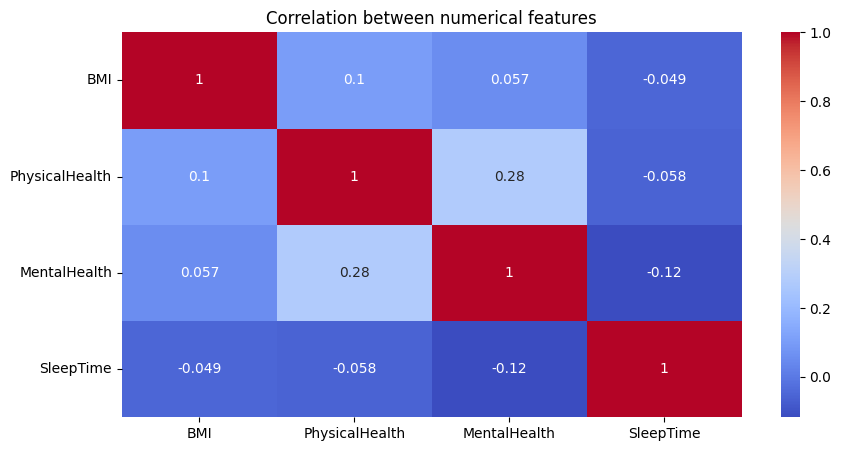

In [27]:
import seaborn as sns
plt.figure(figsize=(10,5))
sns.heatmap(df[cal_num].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation between numerical features")


outlier_hendler and categorical


In [28]:
def outlier_hendler(df,col):
  for i in col:
    Q1=df[i].quantile(0.25)
    Q3=df[i].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    df[i]=df[i].clip(lower_bound,upper_bound)
  return df

In [29]:
outlier_hendler(df,cal_num)

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,10.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,5.0,10.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,5.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,Yes,27.41,Yes,No,No,5.0,0.0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6.0,Yes,No,No
319791,No,29.84,Yes,No,No,0.0,0.0,No,Male,35-39,Hispanic,No,Yes,Very good,5.0,Yes,No,No
319792,No,24.24,No,No,No,0.0,0.0,No,Female,45-49,Hispanic,No,Yes,Good,6.0,No,No,No
319793,No,32.81,No,No,No,0.0,0.0,No,Female,25-29,Hispanic,No,No,Good,11.0,No,No,No


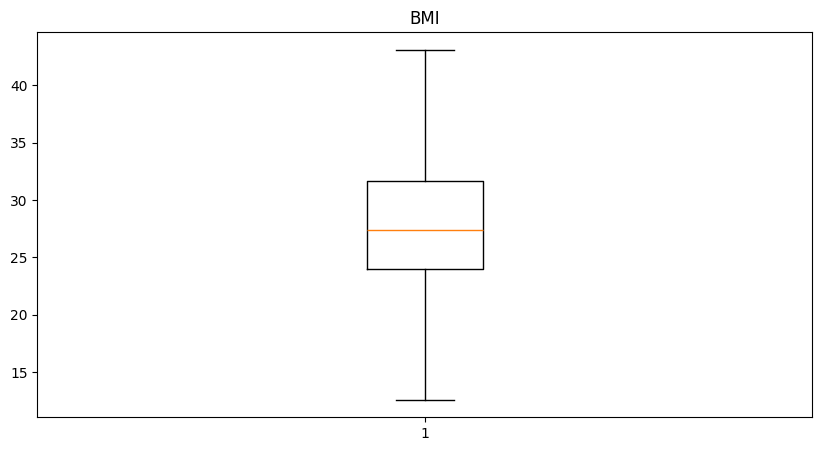

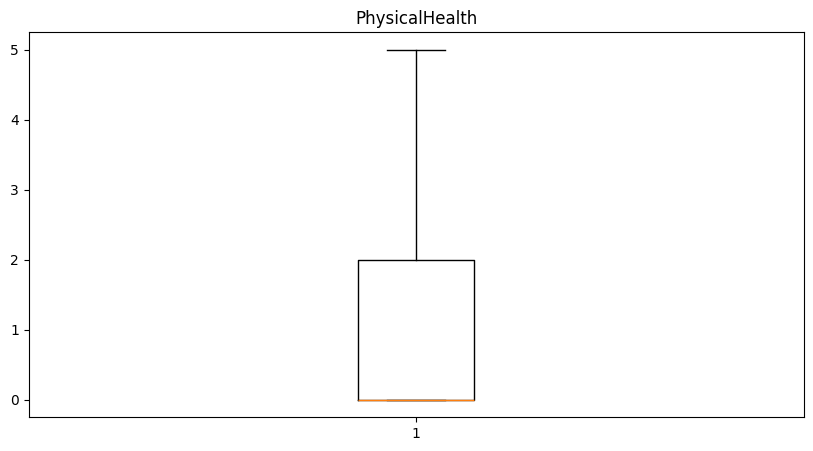

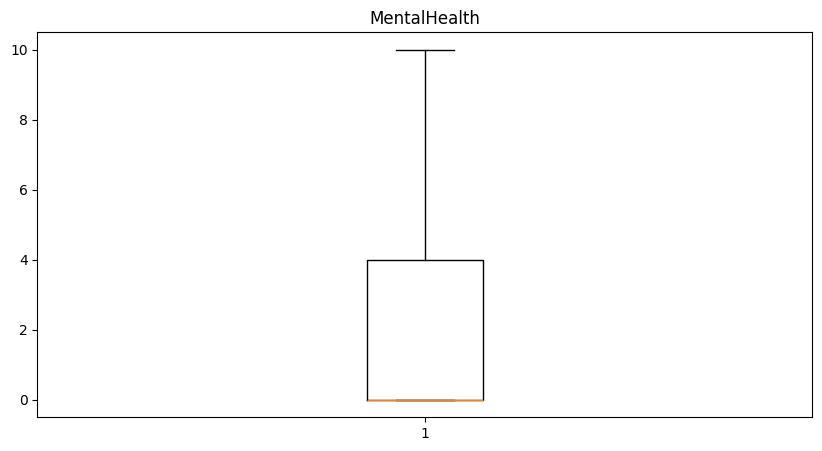

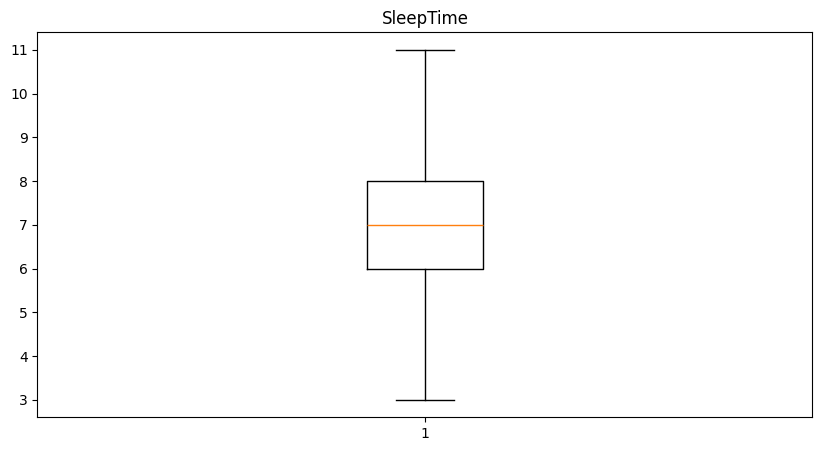

In [30]:
for var in cal_num:
    plt.figure(figsize=(10,5))
    plt.title(var)
    plt.boxplot(df[var])

    plt.show()

In [31]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 7.5 MB/s eta 0:00:00


In [32]:
for var in cal_cate:
    print(var)
    print()
    print(df[var].unique())

HeartDisease

['No' 'Yes']
Smoking

['Yes' 'No']
AlcoholDrinking

['No' 'Yes']
Stroke

['No' 'Yes']
DiffWalking

['No' 'Yes']
Sex

['Female' 'Male']
AgeCategory

['55-59' '80 or older' '65-69' '75-79' '40-44' '70-74' '60-64' '50-54'
 '45-49' '18-24' '35-39' '30-34' '25-29']
Race

['White' 'Black' 'Asian' 'American Indian/Alaskan Native' 'Other'
 'Hispanic']
Diabetic

['Yes' 'No' 'No, borderline diabetes' 'Yes (during pregnancy)']
PhysicalActivity

['Yes' 'No']
GenHealth

['Very good' 'Fair' 'Good' 'Poor' 'Excellent']
Asthma

['Yes' 'No']
KidneyDisease

['No' 'Yes']
SkinCancer

['Yes' 'No']


In [33]:
x=df.drop('HeartDisease',axis=1)
y=df['HeartDisease']

In [34]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [36]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((241373, 17), (60344, 17), (241373,), (60344,))

In [43]:
col2=x_train.select_dtypes(include=['object']).columns
col2

Index(['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex',
       'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

In [41]:
len(cal_cate)

14

In [40]:
type(x_train)

pandas.core.frame.DataFrame

In [44]:
from category_encoders import OneHotEncoder,BinaryEncoder
encode=OneHotEncoder(cols=col2, use_cat_names=True)
x_train=encode.fit_transform(x_train)
x_test=encode.transform(x_test)

In [45]:
# from category_encoders import OrdinalEncoder
# encode=OrdinalEncoder(cols=['AgeCategory'])
# x_train=encode.fit_transform(x_train)
# x_test=encode.transform(x_test)
from sklearn.preprocessing import LabelEncoder
encode=LabelEncoder()
y_train=encode.fit_transform(y_train)
y_test=encode.transform(y_test)


In [46]:
y_train

array([0, 0, 1, ..., 0, 1, 0])

In [47]:
x_train.head(10)

,BMI,Smoking_Yes,Smoking_No,AlcoholDrinking_No,AlcoholDrinking_Yes,Stroke_No,Stroke_Yes,PhysicalHealth,MentalHealth,DiffWalking_No,...,GenHealth_Excellent,GenHealth_Good,GenHealth_Fair,SleepTime,Asthma_No,Asthma_Yes,KidneyDisease_No,KidneyDisease_Yes,SkinCancer_No,SkinCancer_Yes
197559,16.97,1,0,1,0,1,0,0.0,2.0,1,...,0,0,0,7.0,1,0,1,0,1,0
286926,39.16,0,1,1,0,1,0,0.0,0.0,1,...,0,0,0,8.0,1,0,1,0,1,0
250708,26.97,0,1,1,0,0,1,5.0,0.0,1,...,0,0,0,7.0,1,0,0,1,1,0
155034,24.41,1,0,1,0,1,0,0.0,10.0,1,...,0,0,0,5.0,1,0,1,0,1,0
102540,22.15,0,1,1,0,1,0,0.0,0.0,1,...,1,0,0,8.0,1,0,1,0,1,0
14387,24.59,0,1,1,0,1,0,0.0,4.0,1,...,0,0,0,5.0,1,0,1,0,1,0
263838,19.31,0,1,1,0,1,0,0.0,1.0,1,...,1,0,0,8.0,1,0,1,0,1,0
22907,23.63,0,1,1,0,1,0,0.0,6.0,1,...,0,1,0,10.0,1,0,1,0,1,0
44264,28.34,1,0,1,0,1,0,0.0,0.0,1,...,1,0,0,7.0,1,0,1,0,0,1
313007,25.50,0,1,1,0,1,0,5.0,0.0,1,...,0,0,0,7.0,1,0,1,0,1,0


In [48]:
from sklearn.preprocessing import StandardScaler,RobustScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
model=LogisticRegression(random_state=42)
model.fit(x_train,y_train)

LogisticRegression(random_state=42)

In [50]:
print(model.score(x_train,y_train))
print(model.score(x_test,y_test))

0.9113073956076281
0.9108776348932786


In [51]:
y_pre=model.predict(x_test)
print(accuracy_score(y_test,y_pre))
print(classification_report(y_test,y_pre))

0.9108776348932786
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     54894
           1       0.53      0.11      0.18      5450

    accuracy                           0.91     60344
   macro avg       0.73      0.55      0.56     60344
weighted avg       0.88      0.91      0.88     60344



<Axes: >

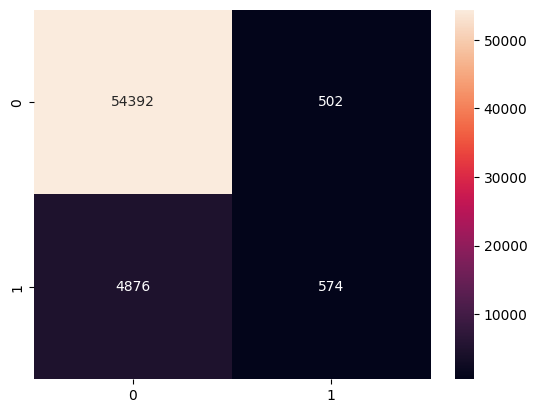

In [52]:
sns.heatmap(confusion_matrix(y_test,y_pre),annot=True,fmt='d')

0.996930062600208
0.8548654381545804
0.8548654381545804
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     54894
           1       0.22      0.25      0.24      5450

    accuracy                           0.85     60344
   macro avg       0.57      0.58      0.58     60344
weighted avg       0.86      0.85      0.86     60344



<Axes: >

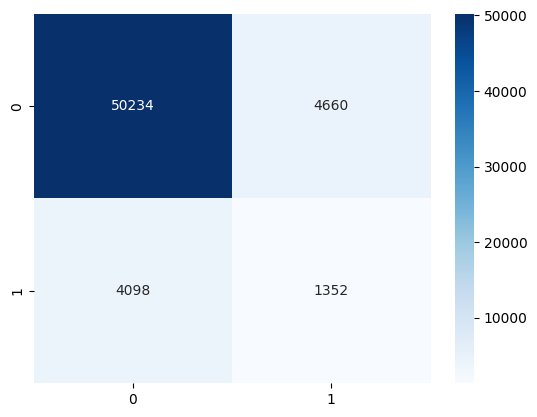

In [53]:
from sklearn.tree import DecisionTreeClassifier
model_tree=DecisionTreeClassifier(random_state=42)
model_tree.fit(x_train,y_train)


print(model_tree.score(x_train,y_train))
print(model_tree.score(x_test,y_test))


y_pre_tree=model_tree.predict(x_test)
print(accuracy_score(y_test,y_pre_tree))
print(classification_report(y_test,y_pre_tree))

sns.heatmap(confusion_matrix(y_test,y_pre_tree),annot=True,fmt='d',cmap="Blues")


RandomForestClassifier  0.996863775152979
RandomForestClassifier  0.8933779663263953
RandomForestClassifier 
 0.8933779663263953
RandomForestClassifier 
               precision    recall  f1-score   support

           0       0.92      0.97      0.94     54894
           1       0.30      0.14      0.19      5450

    accuracy                           0.89     60344
   macro avg       0.61      0.55      0.57     60344
weighted avg       0.86      0.89      0.87     60344



<Axes: >

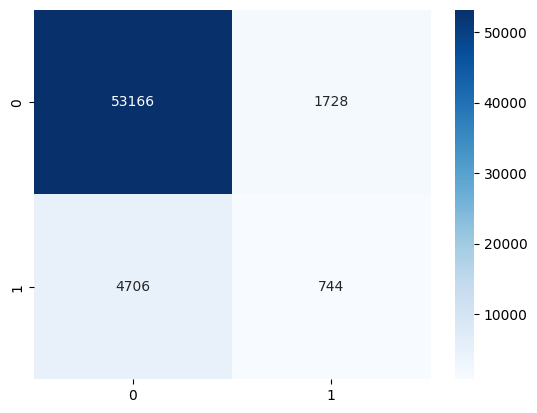

In [55]:
from sklearn.ensemble import RandomForestClassifier
model_forest=RandomForestClassifier(random_state=42)
model_forest.fit(x_train,y_train)

print("RandomForestClassifier ",model_forest.score(x_train,y_train))
print("RandomForestClassifier ",model_forest.score(x_test,y_test))


y_pre_forest=model_forest.predict(x_test)
print("RandomForestClassifier \n",accuracy_score(y_test,y_pre_forest))
print("RandomForestClassifier \n",classification_report(y_test,y_pre_forest))

sns.heatmap(confusion_matrix(y_test,y_pre_forest),annot=True,fmt='d',cmap="Blues")

In [ ]:
# from sklearn.svm import SVC
# model_svm=SVC(random_state=42)
# model_svm.fit(x_train,y_train)

# print("SVC ",model_svm.score(x_train,y_train))
# print("SVC ",model_svm.score(x_test,y_test))


# y_pre_svm=model_svm.predict(x_test)
# print("SVC \n",accuracy_score(y_test,y_pre_svm))
# print("SVC \n",classification_report(y_test,y_pre_svm))

# sns.heatmap(confusion_matrix(y_test,y_pre_svm),annot=True,fmt='d')

SGDClassifier  0.9096377805305481
SGDClassifier  0.9096844756728092
SGDClassifier 
 0.9096844756728092
SGDClassifier 
               precision    recall  f1-score   support

           0       0.91      1.00      0.95     54894
           1       0.00      0.00      0.00      5450

    accuracy                           0.91     60344
   macro avg       0.45      0.50      0.48     60344
weighted avg       0.83      0.91      0.87     60344



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Axes: >

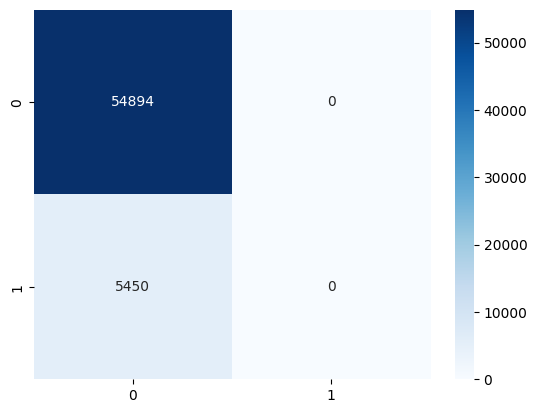

In [56]:
from sklearn.linear_model import SGDClassifier
model_sgd=SGDClassifier(random_state=42)
model_sgd.fit(x_train,y_train)

print("SGDClassifier ",model_sgd.score(x_train,y_train))
print("SGDClassifier ",model_sgd.score(x_test,y_test))

pre_sgd=model_sgd.predict(x_test)
print("SGDClassifier \n",accuracy_score(y_test,pre_sgd))
print("SGDClassifier \n",classification_report(y_test,pre_sgd))

sns.heatmap(confusion_matrix(y_test,pre_sgd),annot=True,fmt='d',cmap="Blues")

Hyperparameters optimize

In [57]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV,StratifiedKFold,cross_val_score
from sklearn.ensemble import AdaBoostClassifier,ExtraTreesClassifier,GradientBoostingClassifier,BaggingClassifier,VotingClassifier,RandomForestClassifier
# from sklearn.ensamble import AdaBoostClassifier,ExtraTreesClassifier,GradientBoostingClassifier,BaggingClassifier,VotingClassifier

In [58]:
single_model={
    "LogisticRegression": LogisticRegression(),
    "DecisionTreeClassifier":DecisionTreeClassifier(),
    "NaiveBayes":GaussianNB(),
    "KNN":KNeighborsClassifier(),
    # "SVC":SVC(),
    "SGDClassifier":SGDClassifier()
}

ensemble_models = {
    # 'RandomForestClassifier': RandomForestClassifier(),
    'ExtraTreesClassifier': ExtraTreesClassifier(),
    'BaggingClassifier': BaggingClassifier(),
    'AdaBoostClassifier': AdaBoostClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'XGBoostClassifier': XGBClassifier()
}


param_grid={
    "LogisticRegression": {"C":[0.001,0.01,0.1,1,10,100]},
    "DecisionTreeClassifier": {"max_depth":[3,4,5,6,7]},
    "NaiveBayes":{},
    "KNN":{"n_neighbors":[3,4,5,6,7,8,9,10]},
    # "RondomForestClassifier":{"n_estimators":[50,80,100]},
    # "SVC":{"C":[0.001,0.01,0.1,1,10,100]},

    "SGDClassifier": {
        "alpha": [0.0001, 0.001, 0.01],
        "loss": ["log_loss", "hinge", "modified_huber"],
        "penalty": ["l2", "l1", "elasticnet"],
        "learning_rate": ["constant", "optimal", "adaptive"],
        "eta0": [0.01, 0.001],
        "max_iter": [100, 200]
    },
    "BaggingClassifier":{"n_estimators":[80,100,150]},
    "AdaBoostClassifier":{"n_estimators":[80,100,150]},
    "ExtraTreesClassifier":{"n_estimators":[90,100,150,200]},
    "GradientBoostingClassifier":{"n_estimators":[90,100,150,200]},
    "XGBoostClassifier":{"n_estimators":[90,100,150,200]},
}







st_cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [61]:

best_models={
}

In [48]:


for name,model in single_model.items():
  grid_search=GridSearchCV(estimator=model,param_grid=param_grid[name],cv=st_cv,n_jobs=-1,scoring='accuracy')
  grid_search.fit(x_train,y_train)
  best_models[name]=grid_search.best_estimator_


In [62]:


for name,model in ensemble_models.items():
  grid_search=GridSearchCV(estimator=model,param_grid=param_grid[name],cv=st_cv,n_jobs=-1,scoring='accuracy')
  grid_search.fit(x_train,y_train)
  best_models[name]=grid_search.best_estimator_



/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyError: 'XGBClassifier'

In [ ]:
estimators = [('RandomForestClassifier', RandomForestClassifier(n_estimators=200)),
('XGBoostClassifier', best_models['XGBoostClassifier']), ('AdaBoostClassifier', best_models['AdaBoostClassifier'])
 ]
voting_clf = VotingClassifier(estimators=estimators, voting='soft')  # or 'hard'
voting_clf.fit(x_train,y_train)
best_models['Voting'] = voting_clf

In [64]:
for name,model in best_models.items():
  print(name)
  y_pred_model=model.predict(x_test)
  print(accuracy_score(y_test,y_pred_model))
  print(classification_report(y_test,y_pred_model))



ExtraTreesClassifier
0.8814629457775421
              precision    recall  f1-score   support

           0       0.92      0.95      0.94     54894
           1       0.26      0.18      0.21      5450

    accuracy                           0.88     60344
   macro avg       0.59      0.56      0.57     60344
weighted avg       0.86      0.88      0.87     60344

BaggingClassifier
0.8963111494100491
              precision    recall  f1-score   support

           0       0.92      0.97      0.94     54894
           1       0.33      0.14      0.19      5450

    accuracy                           0.90     60344
   macro avg       0.62      0.56      0.57     60344
weighted avg       0.87      0.90      0.88     60344

AdaBoostClassifier
0.9104633434972822
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     54894
           1       0.52      0.10      0.17      5450

    accuracy                           0.91     60344
   macro avg 

In [66]:
from xgboost import XGBClassifier
model_xgb=XGBClassifier(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],

}
grid_search=GridSearchCV(estimator=model_xgb,param_grid=param_grid,cv=st_cv,n_jobs=-1,scoring='accuracy')
grid_search.fit(x_train,y_train)

print("training accuracy ",grid_search.score(x_train,y_train))
print("testing accuracy ",grid_search.score(x_test,y_test))

training accuracy  0.911899839667237
testing accuracy  0.9107947766140793


In [67]:
print("best parameter ",grid_search.best_params_)
print("best score ",grid_search.best_score_)
print("best estimator ",grid_search.best_estimator_)

best parameter  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
best score  0.911667831481638
best estimator  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)


0.9107947766140793
              precision    recall  f1-score   support

           0       0.91      0.99      0.95     54894
           1       0.55      0.07      0.12      5450

    accuracy                           0.91     60344
   macro avg       0.73      0.53      0.54     60344
weighted avg       0.88      0.91      0.88     60344



<Axes: >

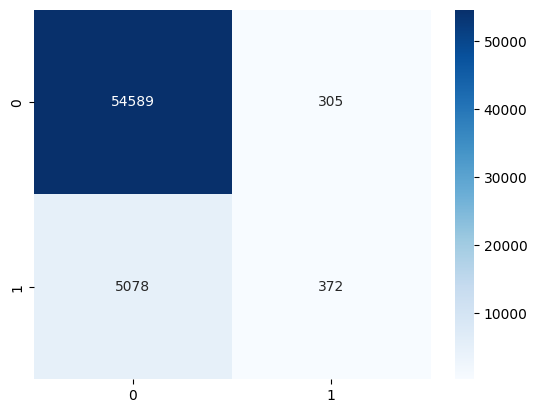

In [69]:
y_pred_xgb=grid_search.best_estimator_.predict(x_test)
print(accuracy_score(y_test,y_pred_xgb))
print(classification_report(y_test,y_pred_xgb))
sns.heatmap(confusion_matrix(y_test,y_pred_xgb),annot=True,fmt='d',cmap="Blues")